# 🚀 Practice Day 05

**📅 Date:** 2026-09-17  
**📁 Category:** Phase 2 · Pandas 심화 GroupBy & Pivot (Round 1/5)

---
# 🎯 Today's Goal
*What am I trying to solve today?*

- Group by more than one column at once (여러 컬럼 기준으로 동시에 groupby)
- Use agg() to compute several metrics in a single pass (agg()로 여러 지표 한 번에 계산)
- Reshape data with pivot_table for row x column comparisons (pivot_table로 행x열 비교 테이블 만들기)

---
# 📂 Dataset

**Dataset Name:** Convenience Store Chain Sales (편의점 체인 판매 데이터)

**Source:** Synthetically generated for practice, fixed random seed (연습용으로 코드에서 직접 생성, seed 고정)

**Description:** Daily sales (USD) for 8 NYC stores (SoHo, Williamsburg, Midtown, Chelsea, Astoria, Park Slope, Financial District, Upper West Side) across 5 product categories (Beverages, Snacks, Rice Balls & Lunch Boxes, Ice Cream, Household Items) x 7 days of the week = 280 rows. Each category has a different weekday-vs-weekend pattern baked in (e.g., lunch boxes sell far more on weekdays, ice cream and snacks sell more on weekends).
(뉴욕 8개 지점, 매출은 USD. 5개 카테고리(음료/과자·스낵/삼각김밥·도시락/아이스크림/생활용품) x 요일(7) = 280행. 카테고리마다 평일/주말 패턴이 다르게 반영되어 있습니다 — 예: 도시락은 평일에, 아이스크림·과자는 주말에 더 잘 팔림.)

## Dataset Preview

In [33]:
# Dataset Preview
import pandas as pd
import numpy as np

np.random.seed(42)
pd.set_option("display.float_format", "{:,.2f}".format)

stores = ['SoHo', 'Williamsburg', 'Midtown', 'Chelsea', 'Astoria', 'Park Slope', 'Financial District', 'Upper West Side']
store_multiplier = {s: np.random.uniform(0.75, 1.3) for s in stores}

categories = ['Beverages', 'Snacks', 'Rice Balls & Lunch Boxes', 'Ice Cream', 'Household Items']
category_base_sales = {
    'Beverages': 4500, 'Snacks': 2800, 'Rice Balls & Lunch Boxes': 3800,
    'Ice Cream': 1500, 'Household Items': 2000,
}
category_base_qty = {
    'Beverages': 380, 'Snacks': 320, 'Rice Balls & Lunch Boxes': 260,
    'Ice Cream': 140, 'Household Items': 90,
}
category_day_pattern = {
    'Beverages': {'weekday': 1.10, 'weekend': 0.90},
    'Snacks': {'weekday': 0.90, 'weekend': 1.30},
    'Rice Balls & Lunch Boxes': {'weekday': 1.40, 'weekend': 0.60},
    'Ice Cream': {'weekday': 0.85, 'weekend': 1.35},
    'Household Items': {'weekday': 0.95, 'weekend': 1.15},
}

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekend_days = {'Saturday', 'Sunday'}

rows = []
for store in stores:
    for cat in categories:
        for day in days:
            day_type = 'weekend' if day in weekend_days else 'weekday'
            pattern = category_day_pattern[cat][day_type]
            sales_amount = int(category_base_sales[cat] * store_multiplier[store] * pattern * np.random.normal(1.0, 0.07))
            quantity_sold = int(category_base_qty[cat] * store_multiplier[store] * pattern * np.random.normal(1.0, 0.09))
            rows.append({
                'store': store,
                'category': cat,
                'day_of_week': day,
                'sales_amount': sales_amount,
                'quantity_sold': quantity_sold,
            })

df = pd.DataFrame(rows)
df.head()

,store,category,day_of_week,sales_amount,quantity_sold
0,SoHo,Beverages,Monday,5255,427
1,SoHo,Beverages,Tuesday,4576,419
2,SoHo,Beverages,Wednesday,4578,382
3,SoHo,Beverages,Thursday,4812,330
4,SoHo,Beverages,Friday,4160,379


## Dataset Information

In [34]:
# Dataset Information
print(df.shape)
df.info()
df.describe()

(280, 5)
<class 'pandas.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   store          280 non-null    str  
 1   category       280 non-null    str  
 2   day_of_week    280 non-null    str  
 3   sales_amount   280 non-null    int64
 4   quantity_sold  280 non-null    int64
dtypes: int64(2), str(3)
memory usage: 11.1 KB


,sales_amount,quantity_sold
count,280.00,280.00
mean,"3,143.26",253.78
std,"1,609.25",140.67
min,891.00,58.00
25%,"1,861.25",119.75
50%,"2,638.00",242.50
75%,"4,221.00",362.50
max,"7,665.00",600.00


---
# ❓ Business Questions

1. What is the total sales amount for each store-category combination? (지점x카테고리별 총 매출은?)
2. For each category, what are the total sales amount and average quantity sold? (카테고리별 총 매출과 평균 판매 수량은?)
3. Using a pivot table, how does average sales amount differ by category and day of week? (피벗 테이블로 봤을 때, 카테고리x요일별 평균 매출은 어떻게 다른가?)
4. Which category shows the biggest weekday-vs-weekend sales difference? (평일과 주말 매출 차이가 가장 큰 카테고리는?)
5. How does total sales amount compare across the 8 stores? (8개 지점의 총 매출을 비교하면 어떤 모습인가?)

---
# 🛠 Skills Used
- [x] Python
- [ ] NumPy
- [x] Pandas — multi-column `groupby`, `agg`, `unstack`, `pivot_table`, `reindex`
  (여러 컬럼 groupby, agg, unstack, 피벗, 요일 순서)
- [ ] SQL
- [x] Matplotlib
- [x] Other: Seaborn `barplot` (mean, `hue=day_type`) 

---
# 🔍 Data Cleaning Check

Things I checked:
- [x] Missing Values — 0
  (결측 없음)
- [x] Duplicate Rows — 0
  (중복 없음)
- [x] Wrong Data Types — store/category/day_of_week are text; sales_amount and quantity_sold are int
  (텍스트 3개, 매출·수량은 정수)
- [ ] Rename Columns — not needed
  (불필요)
- [ ] Drop Columns — not needed
  (불필요)


In [35]:
# Data Cleaning Check — inspect only. Fixes are in Q1–Q3.
# (확인만. 수정은 Q1~Q3)

print("Missing values")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDtypes")
print(df.dtypes)

print("\nColumn names")
print(df.columns.tolist())

obj_cols = df.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(df[obj_cols].nunique())


Missing values
store            0
category         0
day_of_week      0
sales_amount     0
quantity_sold    0
dtype: int64

Duplicate rows: 0

Dtypes
store              str
category           str
day_of_week        str
sales_amount     int64
quantity_sold    int64
dtype: object

Column names
['store', 'category', 'day_of_week', 'sales_amount', 'quantity_sold']

Text columns — unique counts
store          8
category       5
day_of_week    7
dtype: int64


---
# 📊 Analysis

## Question 1

**Question:** What is the total sales amount for each store-category combination? (지점x카테고리별 총 매출은?)

**Result:** Every store has the same category rank: Beverages > Rice Balls & Lunch Boxes > Snacks > Household Items > Ice Cream. Store week totals (USD): Williamsburg **137,190**, Upper West Side **130,557**, Midtown **124,955**, Chelsea **117,943**, SoHo **102,004**, Astoria **91,607**, Park Slope **91,150**, Financial District **84,606**. Largest store is about **1.6x** the smallest.
(모든 지점에서 카테고리 순위가 같음. 지점 주간 합은 Williamsburg 13.7만 - Financial District 8.5만 USD. 최대가 최소의 약 1.6배)

**Insight:** Q1 is a mix-plus-size table. The product mix does not change by neighborhood; Williamsburg vs Financial District is scale. One category ranking can be used chain-wide. Store targets should still differ by size.
(Q1은 구성+규모. 동네마다 잘 팔리는 카테고리가 다르지 않고, 지점 크기만 다름. 카테고리 순위는 전사 공통, 매출 목표는 지점 규모별로)

In [36]:
# Question 1: Total sales_amount for each store x category combination (multi-column groupby)
# (store, category 두 컬럼 기준으로 동시에 groupby하여 총 매출 계산)

# unstack keeps each store as one row, so groups are not mixed
# (지점 묶음을 유지하려면 긴 Series를 정렬하지 말고 펼친다)
store_category_wide = (
    df.groupby(["store", "category"])["sales_amount"]
    .sum()
    .unstack()
)
display(store_category_wide)


category,Beverages,Household Items,Ice Cream,Rice Balls & Lunch Boxes,Snacks
store,,,,,
Astoria,27768,11663,8725,26555,16996
Chelsea,35725,15940,11174,33965,21139
Financial District,25706,11086,8468,24446,14900
Midtown,37739,16566,11896,35777,22977
Park Slope,27936,12234,8569,25444,16967
SoHo,30603,13113,9958,29606,18724
Upper West Side,38804,17975,12913,37204,23661
Williamsburg,42228,17376,13337,39673,24576


## Question 2

**Question:** For each category, what are the total sales amount and average quantity sold? (카테고리별 총 매출과 평균 판매 수량은?)

**Result:** Total sales / avg qty: Beverages **$266,509 / 394.4**, Rice Balls & Lunch Boxes **$252,670 / 311.4**, Snacks **$159,940 / 330.9**, Household Items **$115,953 / 93.9**, Ice Cream **$85,040 / 138.3**. Lunch boxes are **21%** fewer units than beverages but only **5%** lower sales. Snacks sell slightly more units than lunch boxes but **37%** less sales. Household sales are below snacks, with about **one-third** the units. Ice Cream sells more units than Household but is last on sales.
(매출/평균수량. 도시락은 음료보다 수량이 약 21% 적은데 매출은 약 5%만 낮음. 스낵은 도시락과 수량이 비슷한데 매출은 약 37% 낮음. 생활용품은 수량 대비 매출이 큼. 아이스크림은 생활용품보다 더 팔리는데 매출은 꼴등)

**Insight:** If the company ranks categories by units, lunch boxes look weaker than they are and Ice Cream looks stronger than Household. Use **sales** for space, promo, and priority SKU lists. Use **units** only for restocking and staffing. Do not cut Household because the qty column is small, and do not treat Ice Cream as a top line because it sells more pieces than Household.
(수량으로 순위를 매기면 도시락은 과소평가, 아이스크림은 생활용품보다 커 보임. 매대·프로모·우선 SKU는 매출 금액 기준. 수량은 발주·인력용. 생활용품을 수량이 적다고 줄이지 말고, 아이스크림을 더 많이 팔린다고 매출 1선으로 보지 말 것)

In [40]:
# Question 2: For each category, compute total sales_amount AND average quantity_sold together
# (agg()로 카테고리별 두 지표를 한 번에 계산)
category_metrics = (
    df.groupby("category")
    .agg(
        total_sales=("sales_amount", "sum"),
        avg_qty=("quantity_sold", "mean"),
    )
    .sort_values("total_sales", ascending=False)
)
display(category_metrics)


,total_sales,avg_qty
category,,
Beverages,266509,394.39
Rice Balls & Lunch Boxes,252670,311.38
Snacks,159940,330.93
Household Items,115953,93.93
Ice Cream,85040,138.29


## Question 3

**Question:** Using a pivot table, how does average sales amount differ by category and day of week? (피벗 테이블로 봤을 때, 카테고리x요일별 평균 매출은 어떻게 다른가?)

**Result:** Beverages stay about **$4,900-5,150** Mon-Fri, then **$4,259 / $3,972** Sat/Sun (**about -18%** vs weekday mean). Rice Balls & Lunch Boxes about **$5,350-5,490** on weekdays vs **$2,234 / $2,327** on weekend (**about -58%**). Snacks rise Sat/Sun to **$3,473 / $3,619** (weekday about **$2,580**, **about +37%**). Ice Cream about **$1,270-1,325** weekdays vs **$2,119 / $2,050** weekend (**about +61%**). Household about **$1,880-2,000** vs about **$2,390** weekend (**about +23%**).
(음료·도시락은 주말에 하락. 도시락이 낙폭이 가장 큼(약 -58%). 스낵·아이스크림·생활용품은 주말에 상승. 아이스크림이 약 +61%로 가장 큼)

**Insight:** The chain does not have one weekend story. Lunch-box demand is a weekday (office) pattern; ice cream and snacks are weekend. Beverage also eases on Sat/Sun, so a Saturday plan copied from Wednesday will miss both the lunch drop and the snack/ice-cream lift.
(주말 이야기가 카테고리마다 다름. 도시락은 평일(오피스)형, 아이스크림·스낵은 주말형. 수요일 운영을 토요일에 그대로 쓰면 도시락 하락과 스낵·아이스크림 상승을 둘 다 놓침)

In [41]:
# Question 3: Build a pivot table - index=category, columns=day_of_week, values=average sales_amount
# (pivot_table로 카테고리 x 요일 평균 매출 테이블 생성)

# Default column order is alphabetical (Friday, Monday, ...). Reindex to calendar order.
# (기본은 알파벳 순. reindex로 월→일 순)

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

pivot_table = (
    df.pivot_table(
        index="category",
        columns="day_of_week",
        values="sales_amount",
        aggfunc="mean",
    )
    .reindex(columns=day_order)
    .round(2)
)
display(pivot_table)


day_of_week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
category,,,,,,,
Beverages,"4,915.00","5,036.62","5,146.25","5,017.38","4,967.38","4,259.00","3,972.00"
Household Items,"1,919.38","1,877.38","1,911.75","2,003.50","1,995.25","2,387.62","2,399.25"
Ice Cream,"1,325.12","1,288.62","1,268.25","1,300.88","1,277.62","2,119.25","2,050.25"
Rice Balls & Lunch Boxes,"5,353.00","5,453.88","5,488.12","5,379.25","5,348.25","2,233.88","2,327.38"
Snacks,"2,554.50","2,574.62","2,618.00","2,580.12","2,573.50","3,473.00","3,618.75"


---
# 📈 Visualization

**Chart 1:** Weekday vs weekend average sales by category (grouped bar chart) - 카테고리별 평일/주말 평균 매출 비교

**Interpretation:** Weekday bars are higher for Beverages and especially Rice Balls & Lunch Boxes. Weekend bars are higher for Snacks, Ice Cream, and Household Items. Same split as Q3, collapsed to two columns. Ice Cream has the largest weekend lift; lunch boxes have the largest weekday gap.
(음료·도시락은 평일 막대가 높음. 스낵·아이스크림·생활용품은 주말 막대가 높음. Q3와 같은 패턴을 두 그룹으로 본 것. 주말 상승은 아이스크림, 평일 갭은 도시락이 가장 큼)

---

**Chart 2:** Total sales amount by store (bar chart) - 지점별 총 매출

**Interpretation:** Bars are sorted largest to smallest. Williamsburg leads (**$137k**), then Upper West Side and Midtown. Financial District is last (**$85k**). Combined with Q1, this is store size, not a different product mix.
(큰 순 정렬. Williamsburg가 1위 13.7만, Financial District가 8.5만으로 마지막. Q1과 같이 보면 상품 구성 차이가 아니라 매장 규모)

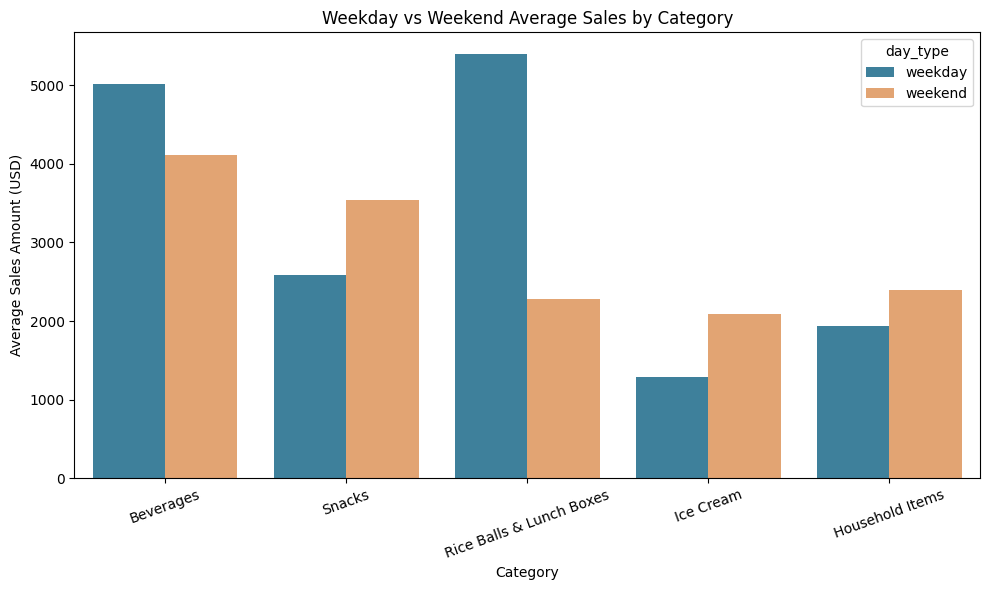

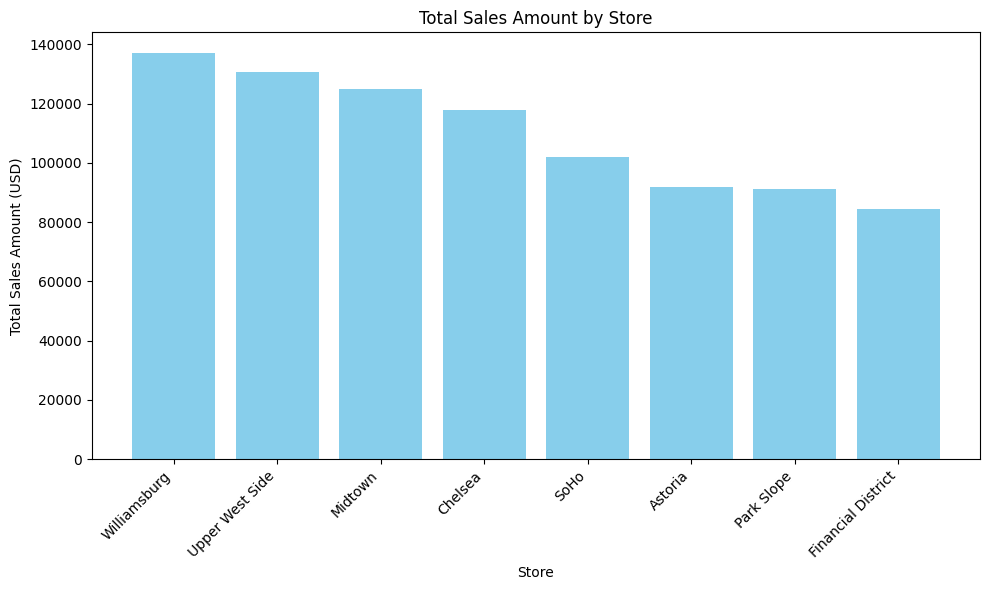

In [39]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1: Weekday vs weekend average sales by category (grouped bar chart)
df['day_type'] = np.where(
    df["day_of_week"].isin(["Saturday", "Sunday"]),
    "weekend",
    "weekday",
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=df,
    x='category',
    y='sales_amount',
    hue='day_type',
    order=['Beverages', 'Snacks', 'Rice Balls & Lunch Boxes', 'Ice Cream', 'Household Items'],
    hue_order=['weekday', 'weekend'],
    palette=['#2E86AB', '#F4A261'],
    errorbar=None,
    ax=ax,
)
ax.set_xlabel('Category')
ax.set_ylabel('Average Sales Amount (USD)')
ax.set_title('Weekday vs Weekend Average Sales by Category')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

# Chart 2: Total sales amount by store (bar chart)
chart_2_data = df.groupby('store')['sales_amount'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(chart_2_data.index, chart_2_data.values, color='skyblue')
ax.set_xlabel('Store')
ax.set_ylabel('Total Sales Amount (USD)')
ax.set_title('Total Sales Amount by Store')
ax.set_xticks(range(len(chart_2_data.index)))
ax.set_xticklabels(chart_2_data.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()


---
# 💼 Business Insights
**What did I discover?**

- Category **rank is the same in every store**. Store totals range **$85k-$137k** (about **1.6x**). Chart 2 is size.
  (카테고리 순위는 전 지점 동일. 지점 합 8.5만-13.7만. 차트 2는 규모)
- Sales rank is not the same as unit rank. Lunch boxes almost match beverage sales with **21%** fewer units. Snacks have lunch-like units but much less sales. Ice Cream has more units than Household and the lowest sales.
  (매출 순위와 수량 순위가 다름. 도시락은 수량 적은데 금액은 음료와 비슷. 스낵은 많이 팔리고 금액은 약함)
- Weekday vs weekend flips by category: lunch boxes **about -58%** on weekend, ice cream **about +61%**.
  (주말 방향이 카테고리마다 다름. 도시락 약 -58%, 아이스크림 약 +61%)
 

---
# 🎯 Business Recommendation
**If I were the Business Analyst...**

1. Do not give all eight stores the same USD target. Williamsburg-scale and Financial District-scale are different boxes.
   (8지점 동일 매출 목표 금지. 큰 매장과 작은 매장을 나눌 것)
2. Do not rank categories by units only. Protect lunch-box sales (near beverage) and do not treat Ice Cream units as equal to Household sales.
   (수량 순으로 카테고리 중요도를 정하지 말 것. 도시락 금액을 지키고, 아이스크림 수량을 생활용품 금액과 같은 급으로 보지 말 것)
3. Staff and stock by day type: weekday lunch boxes, weekend snacks and ice cream. Do not copy a Wednesday plan onto Saturday.
   (평일은 도시락, 주말은 스낵·아이스크림. 수요일 운영을 토요일에 복사하지 말 것)
 

---
# ❌ Mistakes
**What mistakes did I make today?**

- Used `countplot` on a pivot table - that counts rows, and `day_type` was no longer a column.
  (피벗에 countplot. 행 개수를 세고, hue 컬럼도 없음)
- Sorted the MultiIndex Series by value only, which mixed stores.
  (값만 정렬해서 지점 그룹이 섞임)
- Left Q3 weekday columns in alphabetical order before `reindex`.
  (Q3 요일이 알파벳 순. reindex 전)
 

---
# ✅ What I Learned
**Today's biggest lesson**

- For store x category totals, `unstack()` (or `pivot_table`) keeps each store as one row. Value-only `sort_values` does not.
  (지점x카테고리 합은 unstack이 지점을 행으로 유지. 값만 정렬하면 섞임)
- Dict `agg` keeps old column names; `.rename` or named aggregation (`total_sales=("sales_amount", "sum")`) sets new ones.
  (딕셔너리 agg는 원래 컬럼명. rename이거나 named aggregation)
- Seaborn grouped bars want long `df` + `barplot(x, y, hue)`. `countplot` is row counts. `estimator="sum"` if the bar should be a total.
  (seaborn 그룹 막대는 긴 df와 barplot. countplot은 개수. 합이면 estimator="sum")
 

---
# 🧠 Reflection

**What was difficult?**
Building Chart 1 data (weekday vs weekend), MultiIndex sorting, and renaming `agg` columns.
(차트 1용 평일/주말 데이터, 이중 인덱스 정렬, agg 컬럼 이름)

**Why?**
`day_of_week` is seven days, not two groups. `sort_values` on a Series sorts numbers, not store blocks. A dict `agg` does not rename.
(요일이 7개라 2그룹이 아님. Series 정렬은 숫자순. 딕셔너리 agg는 이름을 안 바꿈)

**How did I solve it?**
`np.where` + `isin` for day_type, `unstack` for Q1, `.rename` or named aggregation for Q2, `reindex(columns=day_order)` for Q3, `sns.barplot` on `df`.
(day_type은 isin, Q1은 unstack, Q2는 rename/named agg, Q3는 reindex, 차트는 barplot)

**What would I do differently next time?**
Choose the table shape first (wide vs long) before sorting. Use `barplot` when the y-axis is an amount.
(정렬 전에 표 모양부터. 금액이면 barplot)


---
# ⭐ Self Evaluation

**Understanding**
★★★★★★★☆☆☆
(groupby/pivot는 됨. seaborn hue·정렬 모양은 도움 필요)

**Confidence**
★★★★★★☆☆☆☆

**Difficulty**
★★★★★★★☆☆☆
(차트 데이터 만들기와 표 읽기가 질문보다 어려웠음)

---
# 📌 Tomorrow
*Tomorrow I will learn:*

- Practice Day 06 — SQL basics
  (SQL 기초 연습) 